In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Column names
columns = [
    "type",
    "batch_size",
    "sequence_length",
    "rank",
    "cycle",
    "start_time",
    "end_time"
]

In [3]:
def load_latency_log(file_path):
    rows = []

    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Keep only valid rows with exactly 7 columns
            if len(parts) != 7:
                continue

            try:
                rows.append([
                    parts[0],              # type
                    int(parts[1]),         # batch_size
                    int(parts[2]),         # sequence_length
                    int(parts[3]),         # rank
                    int(parts[4]),         # cycle
                    float(parts[5]),       # start_time
                    float(parts[6])        # end_time
                ])
            except ValueError:
                # Skip garbage lines
                continue

    return pd.DataFrame(rows, columns=columns)

In [4]:
# Load both files
ssm_df = load_latency_log("ssm_gate_latency.log")
tp_df = load_latency_log("tp_latency.log")

# Example
print(ssm_df.head())
print(tp_df.head())

   type  batch_size  sequence_length  rank  cycle     start_time  \
0   SSM           1                4     1      0  965086.439272   
1   SSM           1                4     3      0  965086.439335   
2  Gate           1                4     0      0  965086.443979   
3   SSM           1                4     2      0  965086.439200   
4   SSM           1                4     1      1  965089.164756   

        end_time  
0  965087.158505  
1  965087.159285  
2  965087.159337  
3  965087.159942  
4  965089.262845  
  type  batch_size  sequence_length  rank  cycle    start_time      end_time
0   TP           1                4     1      0  1.024344e+06  1.024344e+06
1   TP           1                4     0      0  1.024344e+06  1.024344e+06
2   TP           1                4     3      0  1.024344e+06  1.024344e+06
3   TP           1                4     2      0  1.024344e+06  1.024344e+06
4   TP           1                4     0      1  1.024363e+06  1.024363e+06


In [5]:
grouped_ssm = (
    ssm_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

grouped_tp = (
    tp_df
    .groupby(["batch_size", "sequence_length", "cycle"])
    .agg(
        start_time=("start_time", "min"),
        end_time=("end_time", "max")
    )
    .reset_index()
)

print(grouped_ssm.head())
print(grouped_tp.head())

   batch_size  sequence_length  cycle     start_time       end_time
0           1                4      0  965086.439200  965087.159942
1           1                4      1  965089.164756  965089.263701
2           1                4      2  965091.274634  965091.361503
3           1                4      3  965093.370511  965093.453659
4           1                4      4  965095.462521  965095.544960
   batch_size  sequence_length  cycle    start_time      end_time
0           1                4      0  1.024344e+06  1.024344e+06
1           1                4      1  1.024363e+06  1.024363e+06
2           1                4      2  1.024382e+06  1.024382e+06
3           1                4      3  1.024401e+06  1.024401e+06
4           1                4      4  1.024420e+06  1.024420e+06


In [6]:
# Compute runtime
grouped_ssm["runtime"] = grouped_ssm["end_time"] - grouped_ssm["start_time"]
grouped_tp["runtime"] = grouped_tp["end_time"] - grouped_tp["start_time"]

# Average runtime across cycles
avg_ssm = (
    grouped_ssm
    .groupby(["batch_size", "sequence_length"])
    .agg(avg_runtime=("runtime", "mean"))
    .reset_index()
)

avg_tp = (
    grouped_tp
    .groupby(["batch_size", "sequence_length"])
    .agg(avg_runtime=("runtime", "mean"))
    .reset_index()
)

print(avg_ssm.head())
print(avg_tp.head())

   batch_size  sequence_length  avg_runtime
0           1                4     0.093245
1           1                8     0.127076
2           1               16     0.176163
3           1               32     1.201537
4           1               64     1.178533
   batch_size  sequence_length  avg_runtime
0           1                4     0.003500
1           1                8     0.004170
2           1               16     0.005443
3           1               32     0.008711
4           1               64     0.015194


In [7]:
merged_df = avg_tp.merge(
    avg_ssm,
    on=["batch_size", "sequence_length"],
    suffixes=("_tp", "_sg")
)

print(merged_df.head())

   batch_size  sequence_length  avg_runtime_tp  avg_runtime_sg
0           1                4        0.003500        0.093245
1           1                8        0.004170        0.127076
2           1               16        0.005443        0.176163
3           1               32        0.008711        1.201537
4           1               64        0.015194        1.178533


In [9]:
merged_df["speedup"] = (
    merged_df["avg_runtime_tp"] / merged_df["avg_runtime_sg"]
)

print(merged_df.head())

   batch_size  sequence_length  avg_runtime_tp  avg_runtime_sg   speedup
0           1                4        0.003500        0.093245  0.037533
1           1                8        0.004170        0.127076  0.032814
2           1               16        0.005443        0.176163  0.030898
3           1               32        0.008711        1.201537  0.007250
4           1               64        0.015194        1.178533  0.012892


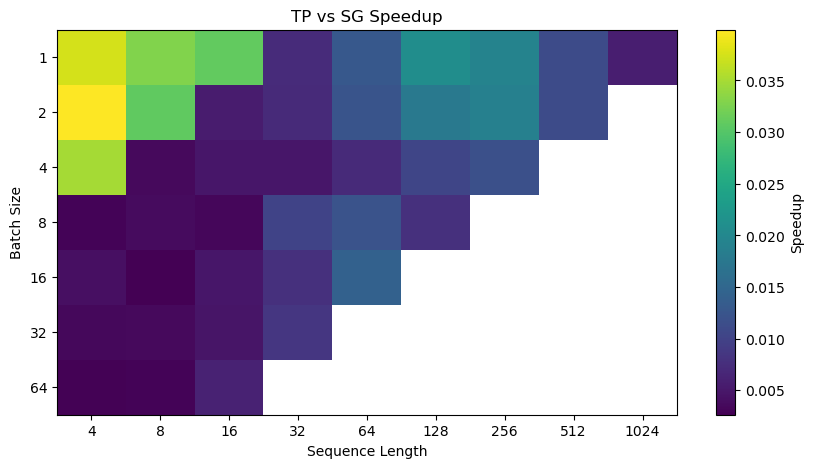

In [11]:
# Create pivot table for heatmap
heatmap_data = merged_df.pivot(
    index="batch_size",
    columns="sequence_length",
    values="speedup"
)

# Plot
plt.figure(figsize=(10, 5))

im = plt.imshow(heatmap_data, aspect="auto")

# Axis labels
plt.xlabel("Sequence Length")
plt.ylabel("Batch Size")
plt.title("TP vs SG Speedup")

# Tick labels
plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

# Color bar
plt.colorbar(im, label="Speedup")

plt.show()